# 07 · Time–frequency analysis and ERD/ERS

**ROBT613 · Brain–Computer Interfaces** | Teaching session + independent lab

## Goal
Compute wavelet power, normalize it to a pre-cue interval and interpret sensorimotor desynchronization.

**Data:** MNE EEGBCI subject 1, run 4

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## The question for today

A whole-trial spectrum shows modest mu power, but does not tell us when imagery changed that rhythm. We use time-frequency analysis to distinguish a sustained rhythm from an event-related reduction.

### By the end you should be able to

- Explain the time–frequency resolution tradeoff.
- Distinguish averaging signals from averaging their power.
- Calculate relative power change in percent and decibels.
- Interpret ERD maps with their baseline and edge limitations.

**How to work:** predict each result before running it, execute one cell at a time, and write a short interpretation. The worked examples use small controlled arrays; the later walkthrough uses the dataset stated above. End-of-lesson exercises contain editable workspaces. A pending exercise message is expected until you complete its function.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: <dataset-cache>


### Why a spectrum is not enough

A Fourier spectrum describes how signal energy is distributed across frequency over the analyzed interval. If 10 Hz activity is strong before an event and weak afterward, one spectrum averages over both states. Time-frequency analysis moves a frequency-sensitive window through the recording. The result has trial, channel, frequency and time axes; every later average should name which of these it removes.

A complex Morlet wavelet combines an oscillation with a Gaussian envelope:

$$\psi_f(t)=e^{i2\pi ft}\exp[-t^2/(2\sigma_t^2)],\qquad \sigma_t=\frac{n_{cycles}}{2\pi f}.$$

Convolution gives a complex coefficient $Z(f,t)$; power is $|Z(f,t)|^2$. More cycles improve frequency selectivity but spread information across a longer time interval. Fewer cycles localize a change more sharply but blur nearby frequencies. The effective kernel extends beyond one standard deviation; do not interpret $\sigma_t$ as the entire support.

In this lesson `n_cycles = freqs / 2` makes the ratio $n_{cycles}/f$ constant. It therefore keeps the approximate temporal width constant across frequencies. A fixed cycle count would instead make lower-frequency wavelets longer. Neither choice is universally correct: select it according to the time and frequency changes you wish to resolve.

### Total and evoked power answer different questions

Averaging trial signals preserves activity with consistent phase and latency. Averaging single-trial power preserves energy even if phase varies. In general,

$$\left|\frac{1}{N}\sum_n Z_n\right|^2\ne\frac{1}{N}\sum_n|Z_n|^2.$$

The first is power of the averaged response; the second is average total power. A rhythm can be strong in every trial yet disappear from the averaged waveform if its phase is not locked to the event. Conversely, a sharp evoked transient contributes broadband time-frequency power without being a sustained oscillation.

### ERD is a comparison with a baseline

Let $P_B(f)$ be mean baseline power at frequency $f$. Two common transformations are

$$\Delta P_{\%}=100\frac{P-P_B}{P_B},\qquad \Delta P_{dB}=10\log_{10}\frac{P}{P_B}.$$

A negative value indicates less power than the chosen baseline. It does not mean negative physical power. A 50% decrease is approximately −3.01 dB; a 50% increase is approximately +1.76 dB. Equal percentage changes upward and downward are not symmetric in decibels.

Compute baseline estimates from a defensible pre-event interval and retain enough surrounding data for convolution. Wavelets centered near an epoch edge have incomplete support and can be distorted by padding. The lesson computes on a wider interval and displays a narrower one. The resulting C3/C4 maps are descriptive sensor-level summaries, not localization or proof of a causal mechanism.

### Worked example · phase cancellation

Create two equally strong rhythms in opposite phase. Compare the power of their average with their average power.

**Before running:** state your prediction and the assumption behind it.

In [2]:
demo_t=np.arange(1000)/100
demo_trials=np.stack([np.sin(2*np.pi*10*demo_t),-np.sin(2*np.pi*10*demo_t)])
print('Power of average:',np.mean(demo_trials.mean(axis=0)**2))
print('Average power:',np.mean(demo_trials**2))

Power of average: 0.0
Average power: 0.4999999999999995


**Read the result.** Zero evoked power does not imply absence of oscillatory activity in the trials.

**Pause and explain:** point to one computed value that supports this interpretation.

### Worked example · the same change in two units

Use baseline power 10 and task powers 5, 10 and 15. Predict the signs and ordering.

**Before running:** state your prediction and the assumption behind it.

In [3]:
demo_baseline=10.
demo_task=np.array([5.,10.,15.])
print(pd.DataFrame({'power':demo_task,'percent':100*(demo_task/demo_baseline-1),'dB':10*np.log10(demo_task/demo_baseline)}))

   power  percent        dB
0    5.0    -50.0 -3.010300
1   10.0      0.0  0.000000
2   15.0     50.0  1.760913


**Read the result.** The baseline maps to zero in both relative representations. The underlying powers remain positive.

**Pause and explain:** point to one computed value that supports this interpretation.

### Guided experiment · wavelet width

Compare fixed cycles with cycles proportional to frequency. Keep track of seconds rather than only the cycle count.

**Before running:** state your prediction and the assumption behind it.

In [4]:
demo_f=np.array([6.,10.,20.,30.])
print(pd.DataFrame({'Hz':demo_f,'sigma_s_fixed_5':5/(2*np.pi*demo_f),'sigma_s_proportional':(demo_f/2)/(2*np.pi*demo_f)}))

     Hz  sigma_s_fixed_5  sigma_s_proportional
0   6.0         0.132629              0.079577
1  10.0         0.079577              0.079577
2  20.0         0.039789              0.079577
3  30.0         0.026526              0.079577


**Read the result.** At low frequencies, fixed-cycle kernels are longer. Baseline and epoch margins should accommodate the longest relevant kernel.

**Pause and explain:** point to one computed value that supports this interpretation.

### Checkpoint · order of averaging

Compare taking a mean after a log with taking a log after a mean.

**Before running:** state your prediction and the assumption behind it.

In [5]:
demo_p=np.array([1.,9.])
print('Mean log power:',np.log10(demo_p).mean())
print('Log mean power:',np.log10(demo_p.mean()))

Mean log power: 0.47712125471966244
Log mean power: 0.6989700043360189


**Read the result.** Nonlinear transforms do not commute with averaging. State whether the reported map is transformed mean power or mean transformed power.

**Pause and explain:** point to one computed value that supports this interpretation.

## Apply the ideas to the complete pipeline

The next stages use the real recording or the explicitly labeled simulation described in the lesson. Keep preprocessing, feature extraction and evaluation decisions visible. Read each stage’s explanation before running its code.

### Method reference for the pipeline

The Morlet wavelet is a complex sinusoid multiplied by a Gaussian: $\psi_f(t)=e^{j2\pi ft}e^{-t^2/(2\sigma_t^2)}$. Time-frequency power is $P(f,t)=|x*\psi_f|^2$. With $n_c$ cycles, $\sigma_t\approx n_c/(2\pi f)$: more cycles sharpen frequency resolution but blur timing.

Baseline-relative power is $10\log_{10}[P(f,t)/P_B(f)]$ in dB. Negative values indicate less power than baseline (ERD); positive values indicate more (ERS). This is a ratio of power, not voltage. Averaging power before normalizing is not generally equivalent to averaging trialwise ratios. We explicitly average trial power first.

Convolution uses data around each point. Pad epochs and interpret only their interior. A late cue-locked difference can be physiological, while a pre-cue difference can come from filtering/wavelet temporal spread or experimental anticipation. No inferential significance is implied by a color plot.

## Load longer epochs for padding
Keep a pre-cue reference and an interior analysis window.

Epochs include extra time around the interval to be displayed. That margin provides support for wavelet convolution and reduces reliance on edge padding in the plotted interior.

In [6]:
from mne.datasets import eegbci
files = eegbci.load_data(1, [4], path=DATA_ROOT, update_path=False)
raw = mne.io.read_raw_edf(files[0], preload=True, verbose=False)
eegbci.standardize(raw)
raw.set_montage('standard_1005')
print(raw)
print('Channel types:', set(raw.get_channel_types()))

raw.filter(2,40)
events,_=mne.events_from_annotations(raw,event_id={'T1':1,'T2':2})
epochs=mne.Epochs(raw,events,{'left':1,'right':2},-1,4,baseline=None,
                  picks=['C3','C4'],preload=True,reject_by_annotation=True)

/tmp/ipykernel_452259/633342437.py:5: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw.set_montage('standard_1005')


<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
Channel types: {'eeg'}


### Inspect and interpret

Compare the extraction interval with the final display interval and baseline. Explain why computing only on the displayed range would be a different operation.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Compute and normalize power
The baseline is −0.8 to −0.2 s. We show −0.5 to 3.5 s to reduce edge interpretation.

Power is computed before trial averaging, then normalized against a pre-event baseline. The logarithmic ratio uses positive power estimates; its zero means baseline-level power. Sensor and condition labels remain explicit in the plot.

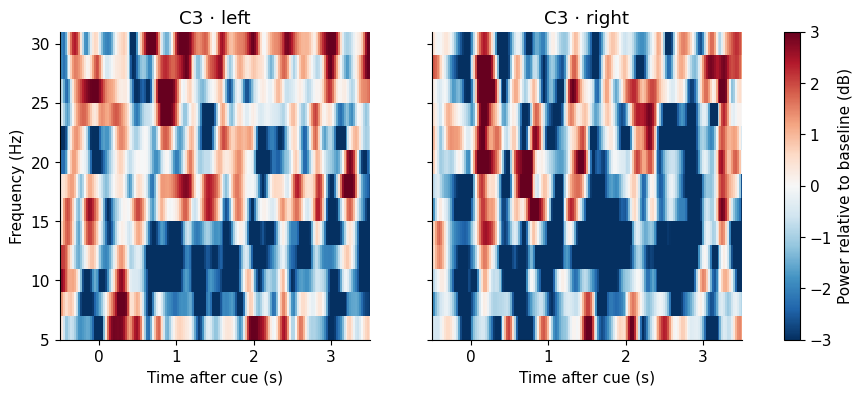

In [7]:
freqs=np.arange(6,31,2)
power=epochs.compute_tfr(method='morlet',freqs=freqs,n_cycles=freqs/2,
                         return_itc=False,average=False,decim=4)
P=power.data
baseline=(power.times>=-.8)&(power.times<=-.2)
fig,axes=plt.subplots(1,2,figsize=(11,4),sharey=True)
for ax,(name,event) in zip(axes,epochs.event_id.items()):
    mean=P[epochs.events[:,2]==event,0].mean(0)
    db=10*np.log10(mean/mean[:,baseline].mean(1,keepdims=True))
    im=ax.pcolormesh(power.times,freqs,db,cmap='RdBu_r',vmin=-3,vmax=3,shading='auto')
    ax.set(xlim=(-.5,3.5),xlabel='Time after cue (s)',title=f'C3 · {name}')
axes[0].set_ylabel('Frequency (Hz)')
fig.colorbar(im,ax=axes,label='Power relative to baseline (dB)'); plt.show()

### Inspect and interpret

Identify a region of reduced or increased power and describe its time/frequency extent without implying a perfectly sharp boundary. Explain how wavelet width contributes to that apparent extent.

**Record in your notes:** the relevant shape/count or metric, the units where applicable, and one limitation of the inference.

## Independent practice

Work through the tasks in order. Exercise 1 includes a small implementation check; passing it verifies the stated example, not every possible input. For the investigations, save a labeled figure or table and a short explanation. Use copies of data objects when changing preprocessing, and preserve any held-out evaluation partition.

**Submission:** your completed notebook, the requested outputs, and a brief exit-ticket response. The notebook runs before exercises are completed; “pending” means your work is still required.

### Exercise 1 · dB conversion

Implement relative_db for positive power and baseline arrays using broadcasting.

In [8]:
def relative_db(power, baseline):
    # TODO: return a power ratio in decibels.
    return None

In [9]:
answer=relative_db(np.array([5.,10.,20.]),10.)
if answer is not None:
    assert np.allclose(answer,[-3.01029996,0,3.01029996]); print('dB checks passed.')
else: print('Exercise pending: implement relative_db.')

Exercise pending: implement relative_db.


**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 2 · Resolution experiment

Repeat the real map with two cycle schedules. Compare temporal smearing and frequency separation using the same color scale.

In [10]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 3 · Baseline sensitivity

Compare two pre-event baseline intervals. Explain whether differences reflect the task or the reference estimate.

In [11]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 4 · Evoked versus total

Compute the spectrum or time-frequency representation of an averaged waveform and compare with mean single-trial power. Explain the difference without calling either incorrect.

In [12]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 5 · ERD feature

Define a pre-specified frequency/time/channel region and extract one ERD feature per trial. State how any data-driven region selection must be confined to training folds.

In [13]:
# Your investigation: add code here.
# Keep the original data and final test partition intact.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

### Exercise 6 · Exit ticket

Write a caption that includes channels, frequency range, cycles, baseline, transform and number of trials.

**Your response:**

- Prediction or rationale: _write here_
- Evidence from your result: _write here_
- Interpretation and limitation: _write here_

## Next steps and sources
[MNE time-frequency analysis](https://mne.tools/stable/auto_tutorials/time-freq/20_sensors_time_frequency.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.